<a href="https://colab.research.google.com/github/ms-starryvoid/ML_Lab_DataSet/blob/main/Programs/Exp5_EM_KMeansComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sample data set
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Info:
 <bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...         

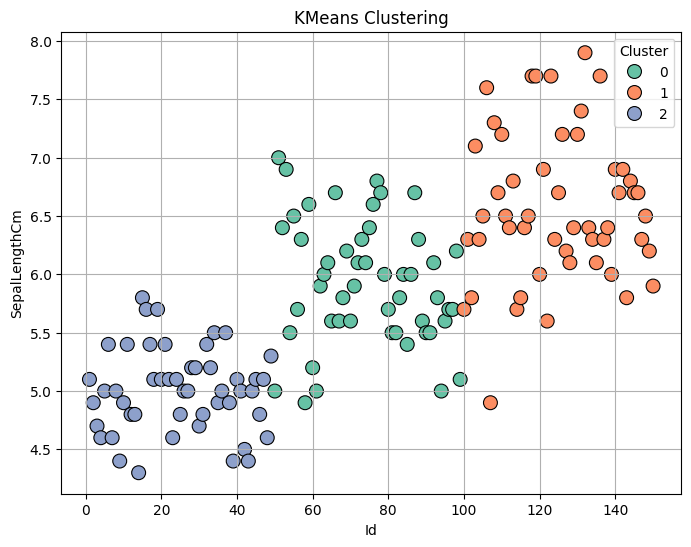

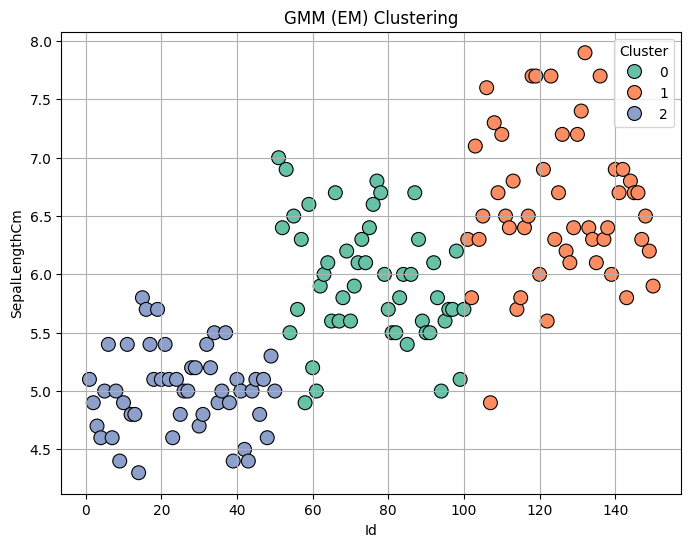

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score,davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
data= pd.read_csv('https://raw.githubusercontent.com/ms-starryvoid/ML_Lab_DataSet/refs/heads/main/Lab_data/Iris.csv')
print("sample data set\n",data.head())
print("\nInfo:\n",data.info)
data= data.drop(columns=['Species'])
#drop user id
if 'User ID' in data.columns:
    data = data.drop(columns=['Species'])
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(data)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(data)

sil_kmeans = silhouette_score(data, kmeans_labels)
sil_gmm = silhouette_score(data, gmm_labels)

db_kmeans = davies_bouldin_score(data, kmeans_labels)
db_gmm = davies_bouldin_score(data, gmm_labels)


print(f"KMeans Silhouette Score: {sil_kmeans:.3f}")
print(f"GMM Silhouette Score: {sil_gmm:.3f}")
print(f"KMeans Davies-Bouldin Score: {db_kmeans:.3f}")
print(f"GMM Davies-Bouldin Score: {db_gmm:.3f}")


def plot_clusters(data, labels, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=data.iloc[:, 0], y=data.iloc[:, 1],
        hue=labels, palette='Set2', s=100, edgecolor='k'
    )
    plt.title(title)
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

plot_clusters(data, kmeans_labels, "KMeans Clustering")
plot_clusters(data, gmm_labels, "GMM (EM) Clustering")